In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('train.csv')

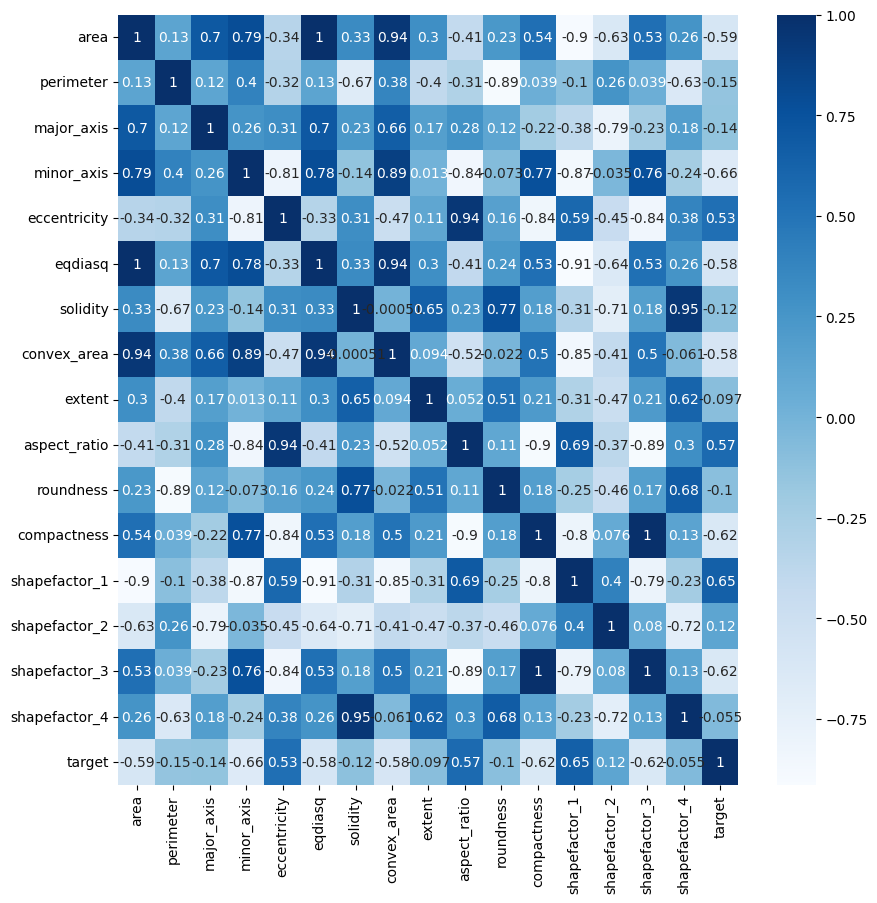

In [3]:
plt.figure(figsize=(10,10))
sns.heatmap(train.corr(), annot=True, cmap='Blues')
plt.show()

In [4]:
features_to_remove = ['shapefactor_4', 'extent', 'eqdiasq', 'convex_area', 'shapefactor_3', 'eccentricity', 'shapefactor_1']
train = train.drop(labels=features_to_remove, axis=1)

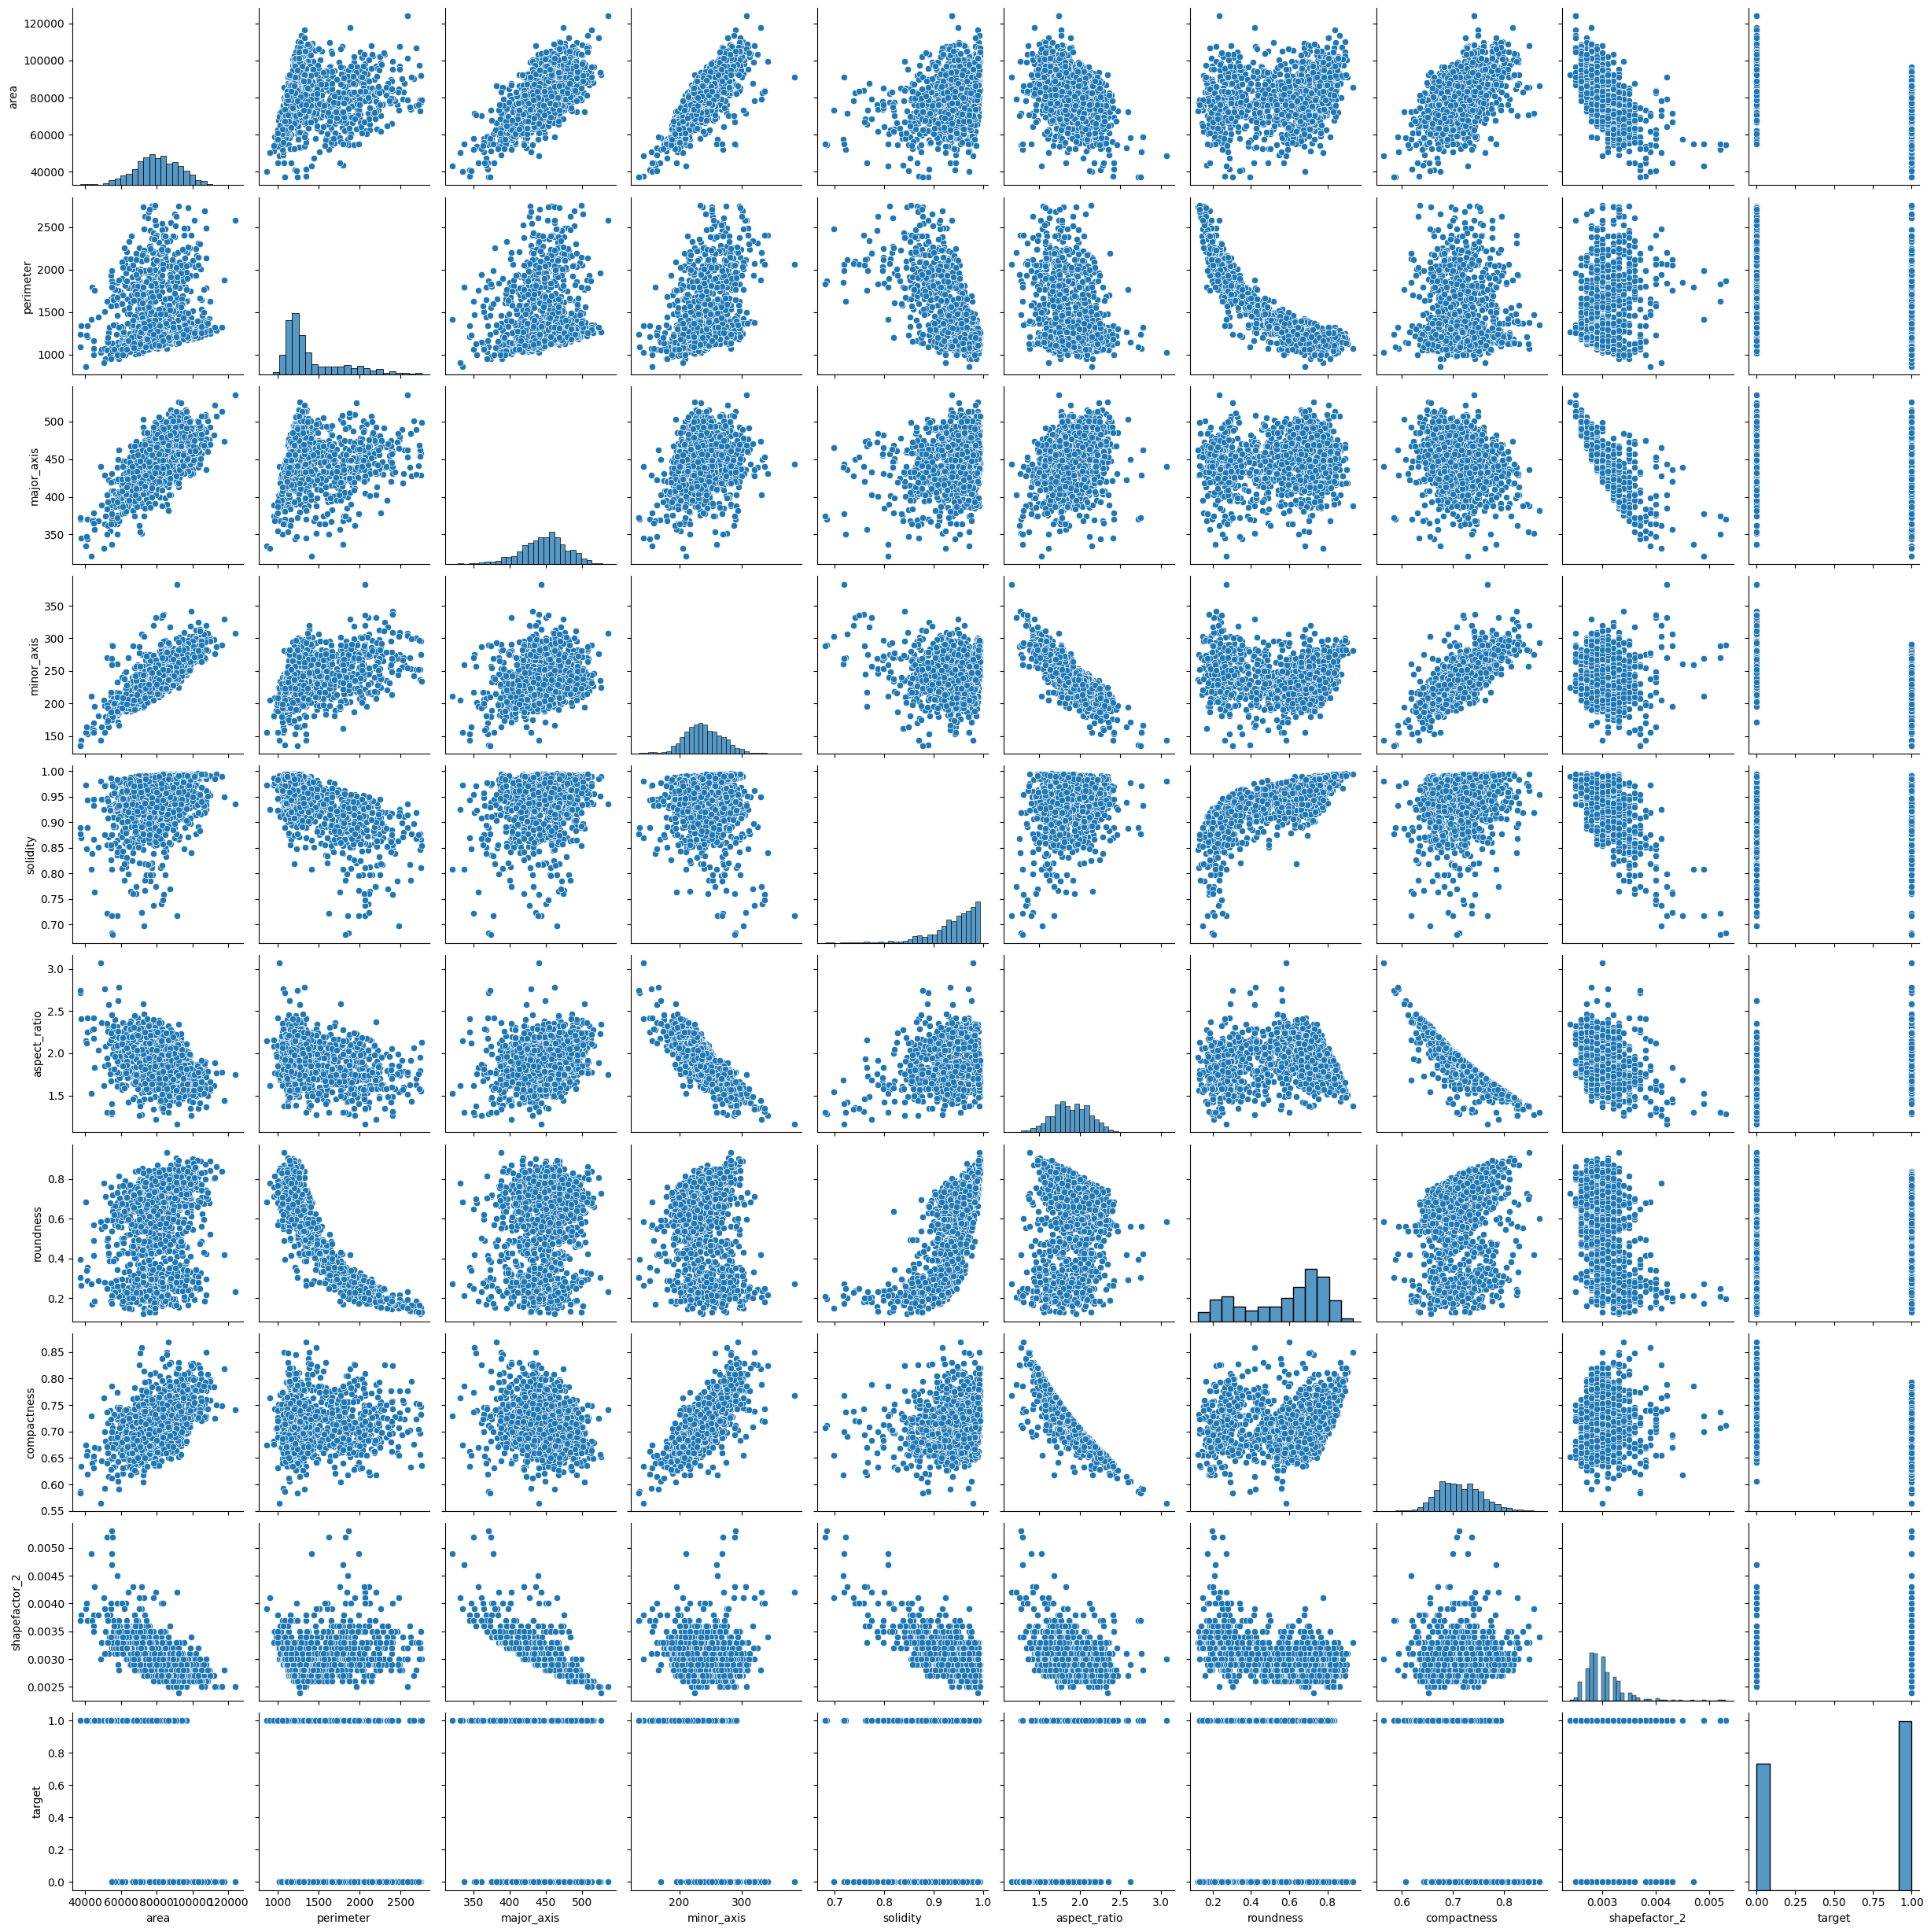

In [5]:
sns.pairplot(train)

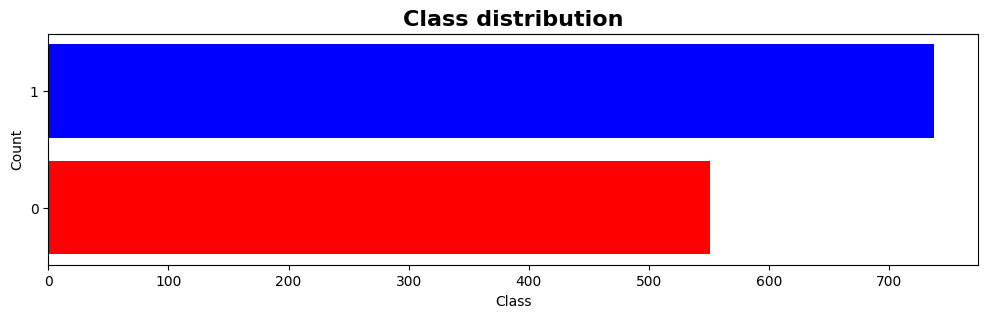

In [3]:
counts = pd.DataFrame(train['target'].value_counts())
plt.figure(figsize=(12, 3))
plt.barh(y=counts.index, width=counts['count'], color=['blue', 'red'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.yticks([0, 1])
plt.title('Class distribution', fontweight='bold', fontsize=16)
plt.show()

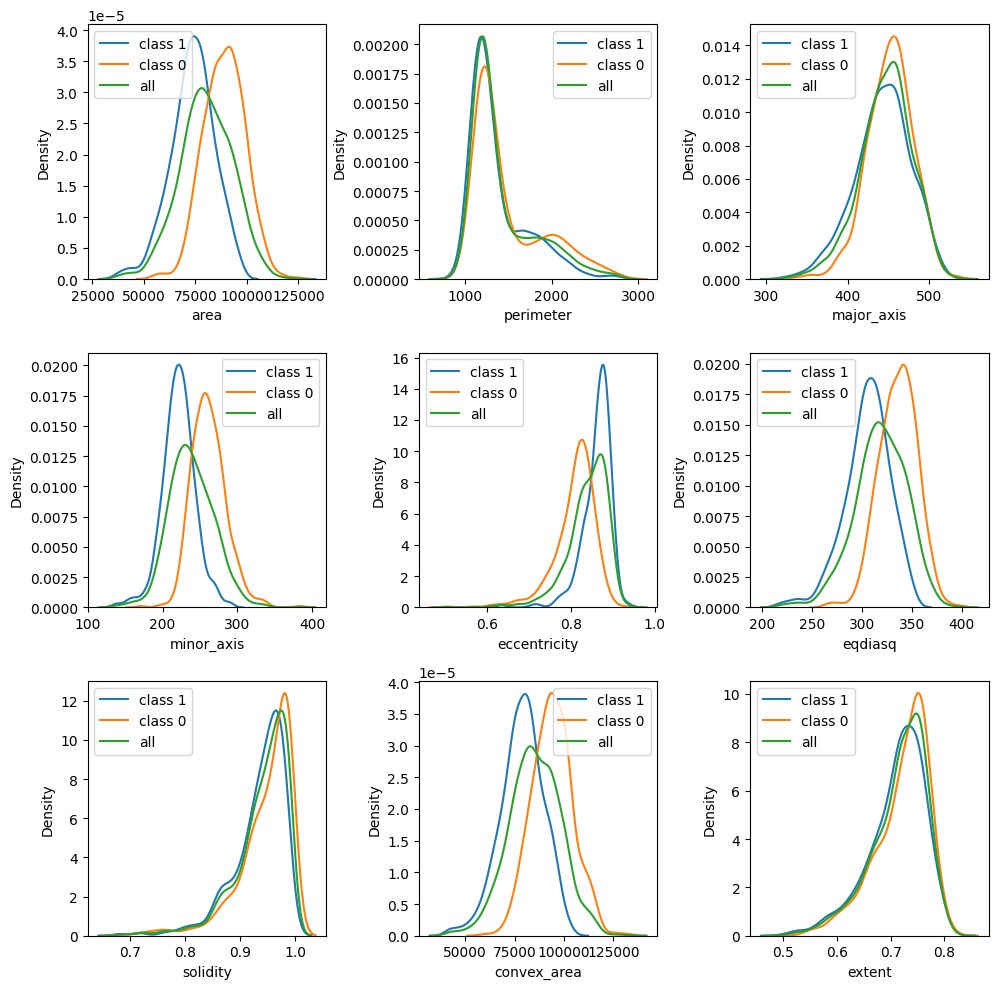

In [4]:
fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(10,10))
features = train.columns

for ax, f in zip(axes.flatten(), features[:-1]):
    sns.kdeplot(data=train[train['target'] == 1][f], ax=ax, label='class 1')
    sns.kdeplot(data=train[train['target'] == 0][f], ax=ax, label='class 0')
    sns.kdeplot(data=train[f], ax=ax, label='all')
    ax.legend()
plt.tight_layout()
plt.show()

In [5]:
train.isna().sum().sum()

np.int64(0)

In [4]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(train, test_size=0.1, stratify=train['target'])

In [5]:
train_scaled = train.copy()
test_scaled = test.copy()

In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
stdsc = StandardScaler() #MinMaxScaler()
train_scaled = stdsc.fit_transform(train)
test_scaled = stdsc.transform(test)
train_scaled = pd.DataFrame(train_scaled, columns=train.columns, index=train.index)
test_scaled = pd.DataFrame(test_scaled, columns=test.columns, index=test.index)

In [7]:
train_scaled['target'] = train['target']
test_scaled['target'] = test['target']

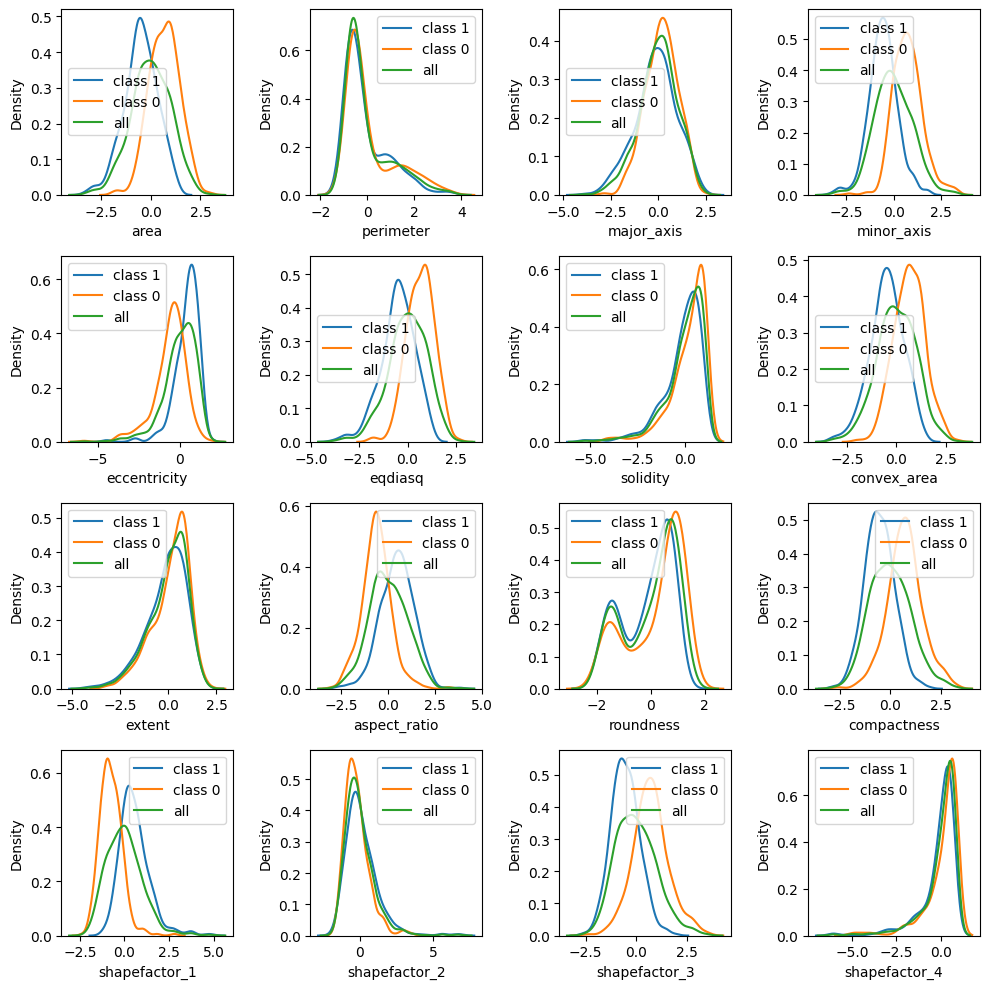

In [8]:
fig, axes = plt.subplots(ncols=4, nrows=4, figsize=(10,10))
features = train_scaled.columns

for ax, f in zip(axes.flatten(), features):
    sns.kdeplot(data=train_scaled[train_scaled['target'] == 1][f], ax=ax, label='class 1')
    sns.kdeplot(data=train_scaled[train_scaled['target'] == 0][f], ax=ax, label='class 0')
    sns.kdeplot(data=train_scaled[f], ax=ax, label='all')
    ax.legend()
plt.tight_layout()
plt.show()

In [9]:
X_train, y_train = train_scaled.drop('target', axis=1), train_scaled['target']

In [10]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [11]:
preds = rf.predict(X_train)

In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y_train, preds)

1.0

In [13]:
X_test, y_test = test_scaled.drop('target', axis=1), test['target']
test_preds = rf.predict(X_test)
accuracy_score(y_test, test_preds)

0.8571428571428571

In [14]:
import torch
import torch.nn as nn
from torch.utils import data
import torch.optim as optim
import tqdm
from sklearn.metrics import precision_recall_curve

In [164]:
model = nn.Sequential(
    nn.Linear(in_features=16, out_features=32),
    nn.LeakyReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(in_features=32, out_features=64),
    nn.LeakyReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(in_features=64, out_features=32),
    nn.LeakyReLU(),
    nn.Linear(in_features=32, out_features=16),
    nn.LeakyReLU(),
    nn.Linear(in_features=16, out_features=4),
    nn.LeakyReLU(),
    nn.Linear(in_features=4, out_features=1),
)

In [197]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, d_model: int, p_drop: float = 0.2):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(d_model * 2, d_model),
        )
        self.drop = nn.Dropout(p_drop)

    def forward(self, x):
        # pre-norm резблок
        h = self.norm1(x)
        h = self.ff(h)
        return x + self.drop(h)

class TabResMLP(nn.Module):
    def __init__(self, in_dim: int, widths=(64, 64, 32), p_drop=0.2):
        super().__init__()
        layers = []
        d_prev = in_dim

        # входной проекционный слой
        d0 = widths[0]
        layers += [nn.Linear(d_prev, d0), nn.GELU(), nn.Dropout(p_drop)]

        # средние блоки
        for d in widths[1:]:
            layers += [nn.Linear(d0, d), nn.GELU(), nn.Dropout(p_drop)]
            # резблок на той же ширине
            layers += [ResidualBlock(d, p_drop)]
            d0 = d

        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(d0, 1)  # один логит

    def forward(self, x):
        z = self.backbone(x)
        logit = self.head(z)
        return logit


In [205]:
model = TabResMLP(in_dim=X_train.shape[1], widths=(64, 64, 32), p_drop=0.25)

In [206]:
train_dataset = data.TensorDataset(torch.tensor(X_train.to_numpy(), dtype=torch.float32), torch.tensor(y_train.to_numpy(), dtype=torch.float32))
test_dataset = data.TensorDataset(torch.tensor(X_test.to_numpy(), dtype=torch.float32), torch.tensor(y_test.to_numpy(), dtype=torch.float32))

train_loader = data.DataLoader(dataset=train_dataset, batch_size=64, drop_last=True)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=len(test_dataset))

In [207]:
optimizer = optim.Adam(params=model.parameters(), lr=0.01, weight_decay=0)
# sheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, factor=0.5, patience=50)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=30)
loss_func = nn.BCEWithLogitsLoss()
epochs = 2000

In [208]:
val_losses, train_losses = [], []
best_accs = []

for _e in range(epochs):
    model.train()
    lm_cnt = 0
    loss_sum = 0

    train_tqdm = tqdm.tqdm(train_loader, leave=False)
    for x, y in train_tqdm:
        pred = model(x)
        
        loss = loss_func(pred.squeeze(), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_cnt += 1
        loss_sum += loss.item()
        train_tqdm.set_description(f'Epoch [{_e + 1}/{epochs}], loss_mean={loss_sum/lm_cnt:.3f}')
    
    model.eval()
    with torch.no_grad():
        x_val, y_val = next(iter(test_loader))
        val_preds = model(x_val).squeeze()
        loss_val = loss_func(val_preds, y_val).item()
        # sheduler.step(loss_val)
        val_losses.append(loss_val)
        train_losses.append(loss_sum / lm_cnt)

        y_val_np = y_val.numpy()
        probs = torch.sigmoid(val_preds).numpy()
        prec, rec, thresholds = precision_recall_curve(y_val_np, probs)
        f1 = 2 * prec * rec / (prec + rec + 1e-8)
        best_idx = np.argmax(f1)
        best_p = thresholds[best_idx]
        best_acc = accuracy_score(y_val_np, probs >= best_p)

        # if best_acc >= 0.915:
        #     break
        
        best_accs.append(best_acc)
        if (_e + 1) % 200 == 0:
            # for param_group in optimizer.param_groups:
            #     print(f'lr={param_group['lr']}') 
            print(f'Epoch [{_e + 1}/{epochs}] | loss_mean={loss_sum/lm_cnt:.3f}, Q_val={loss_val:.3f}, accuracy={best_acc:.2f}, p={best_p:.3f}')
            torch.save(model.state_dict(), f=f'models/epoch_{_e+1}.tar')
    
        

Epoch [200/2000] | loss_mean=0.249, Q_val=0.379, accuracy=0.89, p=0.341


Epoch [400/2000] | loss_mean=0.171, Q_val=0.551, accuracy=0.89, p=0.489


Epoch [600/2000] | loss_mean=0.142, Q_val=0.623, accuracy=0.89, p=0.507


KeyboardInterrupt: 

In [210]:
device = torch.device('mps')
model = TabResMLP(in_dim=X_train.shape[1], widths=(64, 64, 32), p_drop=0.25)
model.to(device)

criterion = nn.BCEWithLogitsLoss()  # или с pos_weight
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=30)

best_val = float('inf'); best_state = None; wait = 0; patience = 100

for epoch in range(600):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device).float().unsqueeze(1)
        optimizer.zero_grad()
        logit = model(xb)
        loss = criterion(logit, yb)
        loss.backward()
        optimizer.step()

    # валидация по всей val выборке
    model.eval()
    with torch.no_grad():
        v_losses, v_logits, v_targets = [], [], []
        for xv, yv in test_loader:
            xv, yv = xv.to(device), yv.to(device).float().unsqueeze(1)
            lv = model(xv)
            v_losses.append(criterion(lv, yv).item())
            v_logits.append(lv.cpu())
            v_targets.append(yv.cpu())
        val_loss = sum(v_losses)/len(v_losses)
    scheduler.step(val_loss)

    # early stopping
    if val_loss < best_val - 1e-4:
        best_val = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

# восстановить лучшие веса
model.load_state_dict(best_state)


<All keys matched successfully>

In [211]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

model.eval()
with torch.no_grad():
    all_logits, all_y = [], []
    for xv, yv in test_loader:
        logits = model(xv.to(device)).cpu().squeeze(1)
        all_logits.append(logits)
        all_y.append(yv)
    logits = torch.cat(all_logits)
    y_val = torch.cat(all_y).numpy()
    probs = torch.sigmoid(logits).numpy()

# по F1
ths = np.linspace(0.05, 0.95, 19)
f1s = [f1_score(y_val, probs >= t) for t in ths]
best_t = ths[int(np.argmax(f1s))]


In [41]:
val_losses = np.array(val_losses)

In [170]:
train_losses = [vl if vl < 1.0 else 1.0 for vl in train_losses]

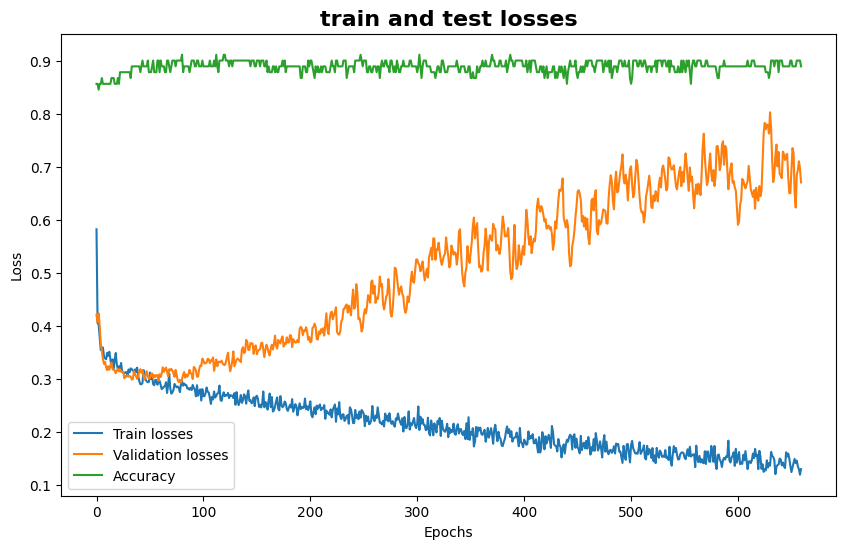

In [212]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train losses')        
plt.plot(val_losses, label='Validation losses')
plt.plot(best_accs, label='Accuracy')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.title(label='train and test losses', fontsize=16, fontweight='bold')
plt.legend()
plt.show()

In [51]:
model.eval()
x_t, y_t = next(iter(test_loader))
finalpreds = model(x_t)

In [213]:
p_vals = []
acc_vals = []
for findp in np.linspace(0, 1.01, 100):
    fp = [1 if p >= best_t else 0 for p in finalpreds.sigmoid()]
    acc = accuracy_score(y_t, fp)
    p_vals.append(findp)
    acc_vals.append(acc)

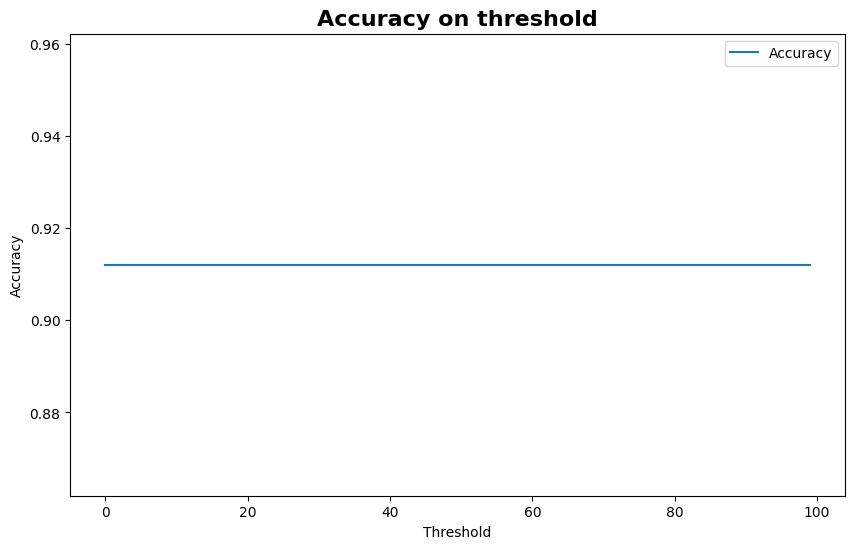

In [214]:
plt.figure(figsize=(10, 6))
plt.plot(acc_vals, label='Accuracy')        
plt.ylabel('Accuracy')
plt.xlabel('Threshold')
plt.title(label='Accuracy on threshold', fontsize=16, fontweight='bold')
plt.legend()
plt.show()

In [215]:
max(acc_vals)

0.9120879120879121

In [172]:
model.load_state_dict(torch.load('models/epoch_1200.tar'))

<All keys matched successfully>

In [173]:
model.eval()
x_t, y_t = next(iter(test_loader))
finalpreds = model(x_t)

In [180]:
p_vals = []
acc_vals = []
best_acc, best_p = 0, 0
for findp in np.linspace(.5, 1.01, 100):
    fp = [1 if p > findp else 0 for p in finalpreds.sigmoid()]
    acc = accuracy_score(y_t, fp)
    p_vals.append(findp)
    acc_vals.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_p = findp
best_acc, best_p

(0.9120879120879121, np.float64(0.5))

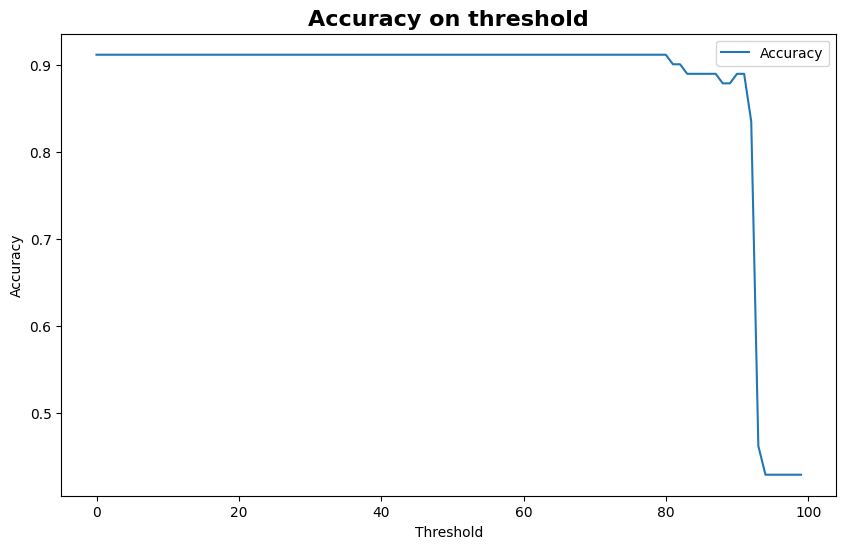

In [181]:
plt.figure(figsize=(10, 6))
plt.plot(acc_vals, label='Accuracy')        
plt.ylabel('Accuracy')
plt.xlabel('Threshold')
plt.title(label='Accuracy on threshold', fontsize=16, fontweight='bold')
plt.legend()
plt.show()

In [182]:
ALLX = torch.concat((test_dataset[:][0], train_dataset[:][0]), dim=0)
ALLY = torch.concat((test_dataset[:][1], train_dataset[:][1]), dim=0)

In [183]:
model.eval()

Sequential(
  (0): Linear(in_features=16, out_features=32, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=32, out_features=64, bias=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): LeakyReLU(negative_slope=0.01)
  (8): Linear(in_features=32, out_features=16, bias=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): Linear(in_features=16, out_features=4, bias=True)
  (11): LeakyReLU(negative_slope=0.01)
  (12): Linear(in_features=4, out_features=1, bias=True)
)

In [184]:
with torch.no_grad():
    preds = model(ALLX)
    probs = torch.sigmoid(preds).numpy()
    ALLYNP = ALLY.numpy()
    p_vals = []
    acc_vals = []
    best_p, best_acc = 0, 0
    for findp in np.linspace(0.4, 0.8, 100):
        fp = [1 if p > findp else 0 for p in finalpreds.sigmoid()]
        acc = accuracy_score(y_t, fp)
        p_vals.append(findp)
        acc_vals.append(acc)
        if acc >= best_acc:
            best_acc = acc
            best_p = findp

best_acc, best_p

(0.9230769230769231, np.float64(0.4686868686868687))

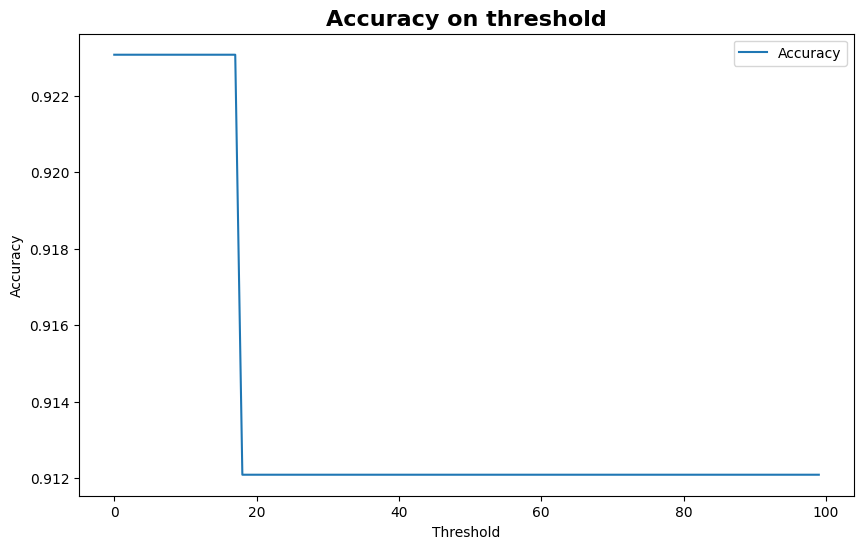

In [185]:
plt.figure(figsize=(10, 6))
plt.plot(acc_vals, label='Accuracy')        
plt.ylabel('Accuracy')
plt.xlabel('Threshold')
plt.title(label='Accuracy on threshold', fontsize=16, fontweight='bold')
plt.legend()
plt.show()

In [216]:
test_data = pd.read_csv('test.csv')
test_data

,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4
0,93313,1862.7260,447.1666,278.4893,0.7824,344.6880,0.9361,99678,0.7607,1.6057,0.3380,0.7708,0.0048,0.0030,0.5942,0.9541
1,78778,2159.5969,439.1004,240.0113,0.8374,316.7069,0.9340,84345,0.7265,1.8295,0.2123,0.7213,0.0056,0.0030,0.5202,0.9517
2,74757,1661.6720,441.6910,225.3914,0.8600,308.5183,0.9359,79873,0.7255,1.9597,0.3402,0.6985,0.0059,0.0030,0.4879,0.9561
3,88074,2199.8889,460.8836,283.3717,0.7886,334.8721,0.8709,101133,0.6922,1.6264,0.2287,0.7266,0.0052,0.0032,0.5279,0.8586
4,79318,2589.4900,429.3032,279.5817,0.7589,317.7905,0.8666,91528,0.6634,1.5355,0.1486,0.7402,0.0054,0.0035,0.5480,0.8414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,82531,1237.1060,493.5974,224.9682,0.8901,324.1631,0.9297,88769,0.7260,2.1941,0.6777,0.6567,0.0060,0.0027,0.4313,0.9463
426,67632,1172.7740,450.7991,199.7804,0.8964,293.4480,0.9534,70939,0.6800,2.2565,0.6179,0.6510,0.0067,0.0030,0.4237,0.9562
427,85519,1200.8210,480.6819,240.4698,0.8659,329.9790,0.9254,92409,0.7129,1.9989,0.7453,0.6865,0.0056,0.0028,0.4713,0.9420
428,86261,1156.8521,456.5374,241.3351,0.8489,331.4075,0.9878,87326,0.6689,1.8917,0.8100,0.7259,0.0053,0.0028,0.5270,0.9968


In [217]:
test_data['target'] = 0

In [218]:
test_data = stdsc.transform(test_data)

In [219]:
test_data.shape

(430, 17)

In [220]:
test_data = pd.DataFrame(test_data, columns=train.columns)

In [221]:
test_data.isna().sum()

area             0
perimeter        0
major_axis       0
minor_axis       0
eccentricity     0
eqdiasq          0
solidity         0
convex_area      0
extent           0
aspect_ratio     0
roundness        0
compactness      0
shapefactor_1    0
shapefactor_2    0
shapefactor_3    0
shapefactor_4    0
target           0
dtype: int64

In [222]:
test_data.drop('target', axis=1, inplace=True)

In [223]:
test_data = torch.tensor(test_data.to_numpy(), dtype=torch.float32)

In [225]:
model.cpu()

TabResMLP(
  (backbone): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.25, inplace=False)
    (6): ResidualBlock(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.25, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
      (drop): Dropout(p=0.25, inplace=False)
    )
    (7): Linear(in_features=64, out_features=32, bias=True)
    (8): GELU(approximate='none')
    (9): Dropout(p=0.25, inplace=False)
    (10): ResidualBlock(
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=32, out_features=64, bias

In [226]:
ans = model(test_data)

In [227]:
anstocsv = [1 if x > best_t else 0 for x in ans.sigmoid()]

In [228]:
anstocsv = np.array(anstocsv)
np.savetxt('answers.csv', anstocsv, fmt='%d', delimiter=',')